In [1]:
import itertools as it

import boto3
import botocore
from cliffs_delta import cliffs_delta
from matplotlib import pyplot as plt
import matplotlib.lines as mlines
import numpy as np
import pandas as pd
from pandas.util import hash_pandas_object
import pingouin as pg
from scipy import stats as scipy_stats
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
import statsmodels.genmod.cov_struct as cov_structs
from teeplot import teeplot as tp


In [2]:
from dishpylib.pyhelpers import make_outattr_metadata
from dishpylib.pyhelpers import print_runtime


In [3]:
print_runtime()


<ipython-input-3-4d790cf6450f>:1: DeprecatedWarning: print_runtime is deprecated. use nbmetalog package instead
  print_runtime()
/usr/local/lib/python3.10/dist-packages/outdated/utils.py:14: OutdatedPackageWarning: The package pingouin is out of date. Your version is 0.5.3, the latest is 0.6.1.
Set the environment variable OUTDATED_IGNORE=1 to disable these warnings.
  return warn(


context: ci
hostname: runnervm9xg2d
interpreter: 3.10.12 (main, Jul 15 2026, 23:40:17) [GCC 11.4.0]
notebook name: 2026-08-29-pcomplexity-gee-0s
notebook path: /home/runner/work/oee4/oee4/binder/2026-08-29-pcomplexity-gee-0s.ipynb
revision: bdac574
timestamp: 2026-09-06T03:29:47Z00:00

IPython==7.16.1
packaging==26.2


In [4]:
teeplot_subdir = "2026-08-29-pcomplexity-gee-0s"


# get data


In [5]:
s3_handle = boto3.resource(
    's3',
    region_name="us-east-2",
    config=botocore.config.Config(
        signature_version=botocore.UNSIGNED,
    ),
)
bucket_handle = s3_handle.Bucket('prq49')

series_profiles, = bucket_handle.objects.filter(
    Prefix=f'endeavor=16/series-profiles/stage=8+what=elaborated/',
)


In [6]:
df = pd.read_csv(
    f's3://prq49/{series_profiles.key}',
    compression='xz',
)
dfdigest = '{:x}'.format( hash_pandas_object( df ).sum() )
dfdigest


<ipython-input-6-747b1fe91af5>:1: DtypeWarning: Columns (286,293,300,301,302,303,305,306,307,308,314,315,316,317,318,324,325,326) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(


'-333308f100cbd3f8'

In [7]:
def make_outattr_metadata():
    return {}


In [8]:
for stint in df['Stint'].unique():
    exec(f'df{stint} = df[ df["Stint"] == {stint} ]')


In [9]:
df["m10"] = df["Stint"] % 10
dfm10 = df[ df["m10"].isin([0, 9]) ]


In [10]:
s3_handle = boto3.resource(
    "s3",
    region_name="us-east-2",
    config=botocore.config.Config(
        signature_version=botocore.UNSIGNED,
    ),
)
bucket_handle = s3_handle.Bucket("prq49")

dfnone = pd.concat(
    [
        pd.read_csv(f"s3://prq49/{item.key}")
        for item in bucket_handle.objects.filter(
            Prefix=f"endeavor=16/external-competitions/stage=2+what=collated/",
        )
    ],
    ignore_index=True,
)
dfnone["kind"] = "none"
print(dfnone["Competition Stint"].unique())
print(dfnone["Competition Series"].unique())


[  1  10 100  11  12  13  14  15  16  17  18  19   2  20  21  22  23  24
  25  26  27  28  29   3  30  31  32  33  34  35  36  37  38  39   4  40
  41  42  43  44  45  46  47  48  49   5  50  51  52  53  54  55  56  57
  58  59   6  60  61  62  63  64  65  66  67  68  69   7  70  71  72  73
  74  75  76  77  78  79   8  80  81  82  83  84  85  86  87  88  89   9
  90  91  92  93  94  95  96  97  98  99]
[16005 16000 16001 16002 16003 16004 16006 16007 16008 16009 16010 16011
 16012 16013 16014 16015 16016 16017 16018 16019 16020 16021 16022 16023
 16024 16025 16026 16027 16028 16029 16030 16031 16032 16033 16034 16035
 16036 16037 16038 16039]


In [11]:
s3_handle = boto3.resource(
    "s3",
    region_name="us-east-2",
    config=botocore.config.Config(
        signature_version=botocore.UNSIGNED,
    ),
)
bucket_handle = s3_handle.Bucket("prq49")

dfbio = pd.concat(
    [
        pd.read_csv(f"s3://prq49/{item.key}")
        for item in bucket_handle.objects.filter(
            Prefix=f"endeavor=16/external-competitions-focalbb-true/stage=2+what=collated/",
        )
    ],
    ignore_index=True,
)
dfbio["kind"] = "eco"
print(dfbio["Competition Stint"].unique())
print(dfbio["Competition Series"].unique())


[ 10 100  11  12  13  14  15  16  17  18  19   2  20  21  22  23  24  25
  26  27  28  29   3  30  31  32  33  34  35  36  37  38  39   4  40  41
  42  43  44  45  46  47  48  49   5  50  51  52  53  54  55  56  57  58
  59   6  60  61  62  63  64  65  66  67  68  69   7  70  71  72  73  74
  75  76  77  78  79   8  80  81  82  83  84  85  86  87  88  89   9  90
  91  92  93  94  95  96  97  98  99]
[16000 16001 16002 16003 16004 16005 16006 16007 16008 16009 16010 16011
 16012 16013 16014 16015 16016 16017 16018 16019 16020 16021 16022 16023
 16024 16025 16026 16027 16028 16029 16030 16031 16032 16033 16034 16035
 16036 16037 16038 16039]


In [12]:
s3_handle = boto3.resource(
    "s3",
    region_name="us-east-2",
    config=botocore.config.Config(
        signature_version=botocore.UNSIGNED,
    ),
)
bucket_handle = s3_handle.Bucket("prq49")

dfabio = pd.concat(
    [
        pd.read_csv(f"s3://prq49/{item.key}")
        for item in bucket_handle.objects.filter(
            Prefix=f"endeavor=16/external-competitions-focalbb/stage=2+what=collated/",
        )
    ],
    ignore_index=True,
)
dfabio["kind"] = "self"
print(dfabio["Competition Stint"].unique())
print(dfabio["Competition Series"].unique())


[  1  10 100  11  12  13  14  15  16  17  18  19   2  20  21  22  23  24
  25  26  27  28  29   3  30  31  32  33  34  35  36  37  38  39   4  40
  41  42  43  44  45  46  47  48  49   5  50  51  52  53  54  55  56  57
  58  59   6  60  61  62  63  64  65  66  67  68  69   7  70  71  72  73
  74  75  76  77  78  79   8  80  81  82  83  84  85  86  87  88  89   9
  90  91  92  93  94  95  96  97  98  99]
[16005 16000 16001 16002 16003 16004 16006 16007 16008 16009 16010 16011
 16012 16013 16014 16015 16016 16017 16018 16019 16020 16021 16022 16023
 16024 16025 16026 16027 16028 16029 16030 16031 16032 16033 16034 16035
 16036 16037 16038 16039]


In [13]:
dfx = pd.concat([dfabio, dfbio, dfnone], ignore_index=True)
dfx["Fitness Differential Focal Sign"] = np.sign(
    dfx["Fitness Differential Focal"],
)
dfx["Series"] = dfx["Competition Series"]
dfx["Stint"] = dfx["Competition Stint"]
dfx["flip series"] = dfx["genome series"] * (dfx["Root ID"] == 1)
dfx["Competitor"] = (
    dfx
    .groupby(["Stint", "Series", "kind", "Competition Repro"])
    ["flip series"]
    .transform("max")
)
dfx = dfx[
    dfx["Root ID"] == 0
].groupby(["Stint", "Series", "kind", "Competitor"])[
    "Focal Prevalence"
].mean().round().reset_index(drop=False)
dfx


,Stint,Series,kind,Competitor,Focal Prevalence
0,1,16005,none,16000.0,1.0
1,1,16005,none,16001.0,0.0
2,1,16005,none,16002.0,0.0
3,1,16005,none,16003.0,0.0
4,1,16005,none,16004.0,0.0
...,...,...,...,...,...
105517,100,16039,self,16035.0,0.0
105518,100,16039,self,16036.0,1.0
105519,100,16039,self,16037.0,0.0
105520,100,16039,self,16038.0,0.0


In [14]:
dfj = dfx.join(
    dfm10[
        [
            "Stint",
            "Series",
            "Fitness Complexity",
            "Flagged Advantageous Sites",
            "Flagged Deleterious Sites",
            "Cardinal Interface Complexity",
            "Cell Interface Complexity",
        ]
    ].set_index(
        ["Stint", "Series"]
    ),
    on=["Stint", "Series"],
    how="inner",
).reset_index(drop=False)
dfj["Favored"] = dfj["Focal Prevalence"] > 0.5
dfj


,index,Stint,Series,kind,Competitor,Focal Prevalence,Fitness Complexity,Flagged Advantageous Sites,Flagged Deleterious Sites,Cardinal Interface Complexity,Cell Interface Complexity,Favored
0,920,9,16000,eco,16000.0,0.0,12.37,13.0,5.0,3.0,2.0,False
1,921,9,16000,eco,16001.0,0.0,12.37,13.0,5.0,3.0,2.0,False
2,922,9,16000,eco,16002.0,0.0,12.37,13.0,5.0,3.0,2.0,False
3,923,9,16000,eco,16003.0,0.0,12.37,13.0,5.0,3.0,2.0,False
4,924,9,16000,eco,16004.0,0.0,12.37,13.0,5.0,3.0,2.0,False
...,...,...,...,...,...,...,...,...,...,...,...,...
95957,105517,100,16039,self,16035.0,0.0,14.67,17.0,0.0,2.0,2.0,False
95958,105518,100,16039,self,16036.0,1.0,14.67,17.0,0.0,2.0,2.0,True
95959,105519,100,16039,self,16037.0,0.0,14.67,17.0,0.0,2.0,2.0,False
95960,105520,100,16039,self,16038.0,0.0,14.67,17.0,0.0,2.0,2.0,False


In [15]:
lpal = {
    "co-evo": "#a3cf73",
    "self": "#5caf96",
    "none": "#f2dfae",
    "Bkgd.": "#ffffff",
}


teeplots/2026-08-29-pcomplexity-gee-0s/other=co-evo+viz=subplots+ext=.pdf
teeplots/2026-08-29-pcomplexity-gee-0s/other=co-evo+viz=subplots+ext=.png


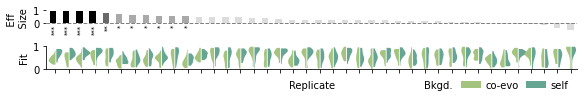

teeplots/2026-08-29-pcomplexity-gee-0s/other=none+viz=subplots+ext=.pdf
teeplots/2026-08-29-pcomplexity-gee-0s/other=none+viz=subplots+ext=.png


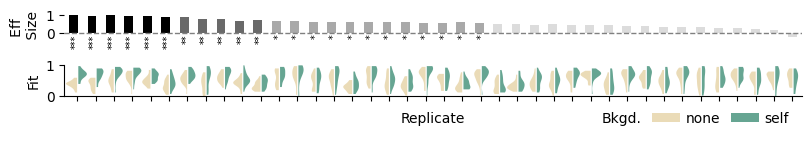

In [16]:
for other in ["eco", "none"]:
    self = "self"
    # 1. Group and prepare the data
    plot_data = dfj[
        dfj["kind"].isin([self, other])
    ].replace(
        {"eco": "co-evo"},
    ).groupby(
        ["Series", "kind", "Stint"]
    ).mean().copy().reset_index()

    # 2. Calculate Wilcoxon metrics using Pingouin
    p_values_greater = {}
    p_values_two_sided = {}
    effect_sizes = {}  # Will hold Rank-Biserial Correlation (RBC)

    if other == "eco":
        other = "co-evo"

    for series in plot_data["Series"].unique():
        series_data = plot_data[plot_data["Series"] == series]

        # Align by "Stint" for exact pairs
        self_df = series_data[series_data["kind"] == self].set_index("Stint")["Focal Prevalence"]
        other_df = series_data[series_data["kind"] == other].set_index("Stint")["Focal Prevalence"]

        aligned = pd.concat([self_df, other_df], axis=1, join="inner")
        aligned.columns = ["self", "other"]

        self_vals = aligned["self"]
        other_vals = aligned["other"]

        if len(self_vals) > 0:
            # Pingouin's wilcoxon returns a DataFrame with stats, p-val, and RBC

            # One-sided test (for sorting)
            res_greater = pg.wilcoxon(self_vals, other_vals, alternative="greater", method="approx")
            p_values_greater[series] = res_greater["p-val"].values[0]

            # Two-sided test (for the column and effect size)
            res_two_sided = pg.wilcoxon(self_vals, other_vals, alternative="two-sided", method="approx")
            p_values_two_sided[series] = res_two_sided["p-val"].values[0]

            # RBC (Rank-Biserial Correlation) is the standard paired effect size
            effect_sizes[series] = res_two_sided["RBC"].values[0]

        else:
            p_values_greater[series] = float('inf')
            p_values_two_sided[series] = float('inf')
            effect_sizes[series] = float('nan')

    # Add the metrics as new columns to the dataframe
    plot_data["Two-Sided P-Value"] = plot_data["Series"].map(p_values_two_sided)
    plot_data["Rank-Biserial Effect"] = plot_data["Series"].map(effect_sizes)
    # plot_data["CLES"] = plot_data["Series"].map(effect_sizes)

    # 3. Sort Series by one-sided p-value (Ascending)
    sorted_series = sorted(p_values_greater.keys(), key=p_values_greater.get)

    # map with " ", *, **, ***
    plot_data["signif"] = plot_data["Two-Sided P-Value"].apply(lambda p: " " if p > 0.05 else "***" if p <= 0.001 else "**" if p <= 0.01 else "*")

    plot_data["order"] = plot_data["Series"].apply(sorted_series.index)

    with tp.teed(
        plt.subplots,
        2,
        1,
        constrained_layout=True,
        figsize=(8, 1.3),
        gridspec_kw={'height_ratios': [0.7, 0.6], "hspace": 0},
        sharey=False,
        teeplot_outattrs={
            "other": other,
        },
        teeplot_subdir=teeplot_subdir,
    ) as (fig, (ax1, ax2)):

        # 4. Generate the plot
        sns.violinplot(
            ax=ax2,
            data=plot_data,
            hue="kind",
            x="Series",
            y="Focal Prevalence",
            split=True,
            inner="quartile",
            cut=0,
            order=sorted_series,
            width=1.35,
            palette=lpal,
            gap=0.1,
            linewidth=0,
            common_norm=True,
            legend=True,
        )

        # Bring back the inner quartile lines by setting their width/color manually
        # Seaborn draws the inner lines as a LineCollection inside the axes
        for collection in ax2.collections:
            # This ensures the inner lines are visible even if linewidth=0 was set globally
            if hasattr(collection, 'set_linewidth'):
                # For modern seaborn, inner lines are often separate paths or lines
                pass

        ax2.set(ylim=(0, 1), ylabel="Fit", xticklabels=[], xlabel="Replicate")
        ax2.set(xlim=(-0.7, None))

        sns.barplot(
            ax=ax1,
            x="order",
            # y="CLES",
            y="Rank-Biserial Effect",
            data=plot_data,
            # marker="o",
            hue="signif",
            palette={
                " ": "gainsboro",
                "*": "darkgray",
                "**": "dimgray",
                "***": "black",
            },
            legend=False,
            gap=0.4,
        )
        ax1.axhline(0, color='gray', linestyle='--', linewidth=1)
        ax1.set_ylim(-1, 1)
        ax1.set_ylabel("   Eff\n    Size")
        ax1.set_xticklabels([])
        ax2.set_xticklabels([])
        ax1.set_xticks([])
        ax1.set_xlabel("")
        ax1.set_yticks([0, 1])
        sns.despine(ax=ax1, left=True, bottom=True)
        sns.despine(ax=ax2)

        unique_bars = plot_data[['order', 'Rank-Biserial Effect', 'signif']].drop_duplicates()
        for _, row in unique_bars.iterrows():
            y_val = -0.04
            ax1.text(
                row['order'] + 0.12,
                y_val,
                row['signif'],
                ha='center',
                va='top',
                color='black',
                clip_on=False,
                rotation=90,
                zorder=10,
                fontsize=7,
                horizontalalignment='right',
                verticalalignment='center',
            )

        handles, labels = ax2.get_legend_handles_labels()
        empty_handle = mlines.Line2D([], [], color="none")
        handles.insert(0, empty_handle)
        labels.insert(0, "Bkgd.")
        ax2.legend(handles, labels)

        sns.move_legend(
            ax2,
            loc="upper right",
            bbox_to_anchor=(1, -0.1),
            ncol=3,
            columnspacing=0.8,
            title=None,
            frameon=False,
            handletextpad=0.4,
        )


# Base


n Series: 40  n rows: 80
['co-evo', 'self']
Categories (2, object): ['co-evo', 'self']
                               GEE Regression Results                               
Dep. Variable:        Q('Focal Prevalence')   No. Observations:                   80
Model:                                  GEE   No. clusters:                       40
Method:                         Generalized   Min. cluster size:                   2
                       Estimating Equations   Max. cluster size:                   2
Family:                            Binomial   Mean cluster size:                 2.0
Dependence structure:          Independence   Num. iterations:                     2
Date:                      Sun, 06 Sep 2026   Scale:                           1.000
Covariance type:                     robust   Time:                         03:30:36
                                                         coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------

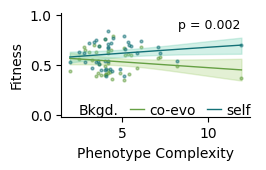

n Series: 40  n rows: 80
['none', 'self']
Categories (2, object): ['none', 'self']
                               GEE Regression Results                               
Dep. Variable:        Q('Focal Prevalence')   No. Observations:                   80
Model:                                  GEE   No. clusters:                       40
Method:                         Generalized   Min. cluster size:                   2
                       Estimating Equations   Max. cluster size:                   2
Family:                            Binomial   Mean cluster size:                 2.0
Dependence structure:          Independence   Num. iterations:                     2
Date:                      Sun, 06 Sep 2026   Scale:                           1.000
Covariance type:                     robust   Time:                         03:30:36
                                                         coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------

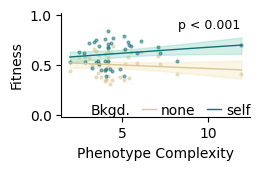

In [17]:
dfjx = dfj[
    dfj["Stint"].isin(range(10, 101, 10))
].groupby(["Series", "kind", "Stint"]).mean().reset_index().groupby(
    ["Series", "kind"],
).mean().reset_index(
    drop=False,
)

fas = "Cardinal Interface Complexity"

for other in ["eco", "none"]:
    d = dfjx[
        dfjx["kind"].isin(["self", other])
    ].copy().replace({"eco": "co-evo"}).copy()
    if other == "eco":
        other = "co-evo"
    d["kind"] = pd.Categorical(
        d["kind"],
        categories=[other, "self"],
    )

    print("n Series:", d["Series"].nunique(), " n rows:", len(d))
    print(d["kind"].unique())

    gee = smf.gee(
        "Q('Focal Prevalence') ~ C(kind) * Q('Cardinal Interface Complexity')",
        groups="Series",
        data=d,
        family=sm.families.Binomial(),
        # time="Stint",
        # cov_struct=cov_structs.Autoregressive(
        #     grid=True,
        # ),
    ).fit()
    print(gee.summary())
    print(gee.cov_struct.summary())  # within-Series correlation

    cic = "Cardinal Interface Complexity"
    light_palette = {"self": "#6dceb1", "co-evo": "#a3cf73", "none": "#f2dfae"}
    dark_palette = {"self": "#137177", "co-evo": "#66a044", "none": "#dac796"}

    grid = np.linspace(d[cic].min(), d[cic].max(), 100)

    with tp.teed(
        plt.subplots,
        figsize=(2.7, 1.8),
        teeplot_outattrs={"what": "base", "other": other},
        teeplot_subdir=teeplot_subdir,
    ) as (fig, ax):
        for kind in [other, "self"]:
            newdata = pd.DataFrame({"kind": kind, cic: grid})
            pred = gee.get_prediction(newdata)
            mean = pred.predicted_mean
            ci = pred.conf_int()

            ax.plot(grid, mean, color=dark_palette[kind], lw=1, label=kind)
            ax.fill_between(
                grid, ci[:, 0], ci[:, 1], color=light_palette[kind], alpha=0.3
            )

            sub = d[d["kind"] == kind]
            ax.scatter(
                sub[cic],
                sub["Focal Prevalence"],
                color=dark_palette[kind],
                s=4,
                alpha=0.5,
                edgecolor=dark_palette[kind],
            )

        ax.set_xlabel("Phenotype Complexity")
        ax.set_ylabel("Fitness")
        ax.set_ylim(-0.02, 1.02)
        # ax.set_xlim(0, None)
        ax.legend(frameon=False, title="Background", fontsize=8)
        fig.tight_layout()
        sns.despine()

        handles, labels = ax.get_legend_handles_labels()
        empty_handle = mlines.Line2D([], [], color="none")
        handles.insert(0, empty_handle)
        labels.insert(0, "Bkgd.")
        ax.legend(handles, labels)
        sns.move_legend(
            ax,
            loc="upper right",
            bbox_to_anchor=(1.07, 0.25),
            ncol=3,
            columnspacing=0.8,
            title=None,
            frameon=False,
            handletextpad=0.4,
            handlelength=1.0,
        )

        interaction_key = "C(kind)[T.self]:Q('Cardinal Interface Complexity')"
        p_val = gee.pvalues.get(interaction_key, gee.pvalues.iloc[-1])

        # Format the p-value string
        p_text = "p < 0.001" if p_val < 0.001 else f"p = {p_val:.3f}"

        # Add to the upper right corner using axes coordinates
        ax.text(
            0.95, 0.95,           # X and Y coordinates (95% of the way to the top/right)
            p_text,
            transform=ax.transAxes, # Use axes bounding box, not data units
            ha="right",           # Align the right edge of the text to 0.95
            va="top",             # Align the top edge of the text to 0.95
            fontsize=9,
            color="black"
        )


# Exclude 16005


n Series: 39  n rows: 78
                               GEE Regression Results                               
Dep. Variable:        Q('Focal Prevalence')   No. Observations:                   78
Model:                                  GEE   No. clusters:                       39
Method:                         Generalized   Min. cluster size:                   2
                       Estimating Equations   Max. cluster size:                   2
Family:                            Binomial   Mean cluster size:                 2.0
Dependence structure:          Independence   Num. iterations:                     2
Date:                      Sun, 06 Sep 2026   Scale:                           1.000
Covariance type:                     robust   Time:                         03:30:37
                                                         coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------

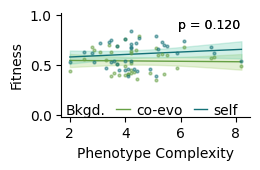

n Series: 39  n rows: 78
                               GEE Regression Results                               
Dep. Variable:        Q('Focal Prevalence')   No. Observations:                   78
Model:                                  GEE   No. clusters:                       39
Method:                         Generalized   Min. cluster size:                   2
                       Estimating Equations   Max. cluster size:                   2
Family:                            Binomial   Mean cluster size:                 2.0
Dependence structure:          Independence   Num. iterations:                     2
Date:                      Sun, 06 Sep 2026   Scale:                           1.000
Covariance type:                     robust   Time:                         03:30:37
                                                         coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------

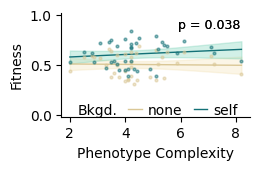

In [18]:
dfjx = dfj[
    dfj["Stint"].isin(range(10, 101, 10))
    & (dfj["Series"] != 16005)
].groupby(["Series", "kind", "Stint"]).mean().reset_index().groupby(
    ["Series", "kind"],
).mean().reset_index(
    drop=False,
)

fas = "Cardinal Interface Complexity"

for other in ["eco", "none"]:
    d = dfjx[
        dfjx["kind"].isin(["self", other])
    ].copy().replace({"eco": "co-evo"}).copy()
    if other == "eco":
        other = "co-evo"
    d["kind"] = pd.Categorical(
        d["kind"],
        categories=[other, "self"],
    )

    print("n Series:", d["Series"].nunique(), " n rows:", len(d))

    gee = smf.gee(
        "Q('Focal Prevalence') ~ C(kind) * Q('Cardinal Interface Complexity')",
        groups="Series",
        data=d,
        family=sm.families.Binomial(),
        # time="Stint",
        # cov_struct=cov_structs.Autoregressive(
        #     grid=True,
        # ),
    ).fit()
    print(gee.summary())
    print(gee.cov_struct.summary())  # within-Series correlation

    cic = "Cardinal Interface Complexity"
    light_palette = {"self": "#6dceb1", "co-evo": "#a3cf73", "none": "#f2dfae"}
    dark_palette = {"self": "#137177", "co-evo": "#66a044", "none": "#dac796"}

    grid = np.linspace(d[cic].min(), d[cic].max(), 100)

    with tp.teed(
        plt.subplots,
        figsize=(2.7, 1.8),
        teeplot_outattrs={"what": "exclude", "other": other},
        teeplot_subdir=teeplot_subdir,
    ) as (fig, ax):
        for kind in [other, "self"]:
            newdata = pd.DataFrame({"kind": kind, cic: grid})
            pred = gee.get_prediction(newdata)
            mean = pred.predicted_mean
            ci = pred.conf_int()

            ax.plot(grid, mean, color=dark_palette[kind], lw=1, label=kind)
            ax.fill_between(
                grid, ci[:, 0], ci[:, 1], color=light_palette[kind], alpha=0.3
            )

            sub = d[d["kind"] == kind]
            ax.scatter(
                sub[cic],
                sub["Focal Prevalence"],
                color=dark_palette[kind],
                s=4,
                alpha=0.5,
                edgecolor=dark_palette[kind],
                zorder=10,
            )

        ax.set_xlabel("Phenotype Complexity")
        ax.set_ylabel("Fitness")
        ax.set_ylim(-0.02, 1.02)
        # ax.set_xlim(0, None)
        ax.legend(frameon=False, title="Background", fontsize=8)
        fig.tight_layout()
        sns.despine()

        handles, labels = ax.get_legend_handles_labels()
        empty_handle = mlines.Line2D([], [], color="none")
        handles.insert(0, empty_handle)
        labels.insert(0, "Bkgd.")
        ax.legend(handles, labels)
        sns.move_legend(
            ax,
            loc="upper right",
            bbox_to_anchor=(1, 0.25),
            ncol=3,
            columnspacing=0.8,
            title=None,
            frameon=False,
            handletextpad=0.4,
            handlelength=1.0,
        )
        interaction_key = "C(kind)[T.self]:Q('Cardinal Interface Complexity')"
        p_val = gee.pvalues.get(interaction_key, gee.pvalues.iloc[-1])

        # Format the p-value string
        p_text = "p < 0.001" if p_val < 0.001 else f"p = {p_val:.3f}"

        # Add to the upper right corner using axes coordinates
        ax.text(
            0.95, 0.95,           # X and Y coordinates (95% of the way to the top/right)
            p_text,
            transform=ax.transAxes, # Use axes bounding box, not data units
            ha="right",           # Align the right edge of the text to 0.95
            va="top",             # Align the top edge of the text to 0.95
            fontsize=9,
            color="black"
        )
        interaction_key = "C(kind)[T.self]:Q('Cardinal Interface Complexity')"
        p_val = gee.pvalues.get(interaction_key, gee.pvalues.iloc[-1])

        # Format the p-value string
        p_text = "p < 0.001" if p_val < 0.001 else f"p = {p_val:.3f}"

        # Add to the upper right corner using axes coordinates
        ax.text(
            0.95, 0.95,           # X and Y coordinates (95% of the way to the top/right)
            p_text,
            transform=ax.transAxes, # Use axes bounding box, not data units
            ha="right",           # Align the right edge of the text to 0.95
            va="top",             # Align the top edge of the text to 0.95
            fontsize=9,
            color="black"
        )


# Disaggregate


n Series: 40  n rows: 800
['co-evo', 'self']
Categories (2, object): ['co-evo', 'self']
                               GEE Regression Results                               
Dep. Variable:        Q('Focal Prevalence')   No. Observations:                  784
Model:                                  GEE   No. clusters:                       40
Method:                         Generalized   Min. cluster size:                  18
                       Estimating Equations   Max. cluster size:                  20
Family:                            Binomial   Mean cluster size:                19.6
Dependence structure:        Autoregressive   Num. iterations:                     5
Date:                      Sun, 06 Sep 2026   Scale:                           1.000
Covariance type:                     robust   Time:                         03:30:38
                                                         coef    std err          z      P>|z|      [0.025      0.975]
----------------------------

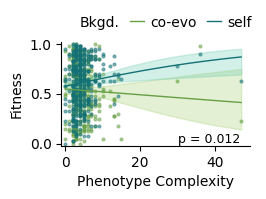

n Series: 40  n rows: 800
['none', 'self']
Categories (2, object): ['none', 'self']
                               GEE Regression Results                               
Dep. Variable:        Q('Focal Prevalence')   No. Observations:                  784
Model:                                  GEE   No. clusters:                       40
Method:                         Generalized   Min. cluster size:                  18
                       Estimating Equations   Max. cluster size:                  20
Family:                            Binomial   Mean cluster size:                19.6
Dependence structure:        Autoregressive   Num. iterations:                     6
Date:                      Sun, 06 Sep 2026   Scale:                           1.000
Covariance type:                     robust   Time:                         03:30:38
                                                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------

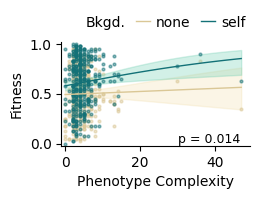

In [19]:
dfjx = dfj[
    dfj["Stint"].isin(range(10, 101, 10))
].groupby(["Series", "kind", "Stint"]).mean().reset_index(
    drop=False,
)

fas = "Cardinal Interface Complexity"

for other in ["eco", "none"]:
    d = dfjx[
        dfjx["kind"].isin(["self", other])
    ].copy().replace({"eco": "co-evo"}).copy()
    if other == "eco":
        other = "co-evo"
    d["kind"] = pd.Categorical(
        d["kind"],
        categories=[other, "self"],
    )

    print("n Series:", d["Series"].nunique(), " n rows:", len(d))
    print(d["kind"].unique())

    gee = smf.gee(
        "Q('Focal Prevalence') ~ C(kind) * Q('Cardinal Interface Complexity')",
        groups="Series",
        data=d,
        family=sm.families.Binomial(),
        time="Stint",
        cov_struct=cov_structs.Autoregressive(
            grid=True,
        ),
    ).fit()
    print(gee.summary())
    print(gee.cov_struct.summary())  # within-Series correlation

    cic = "Cardinal Interface Complexity"
    light_palette = {"self": "#6dceb1", "co-evo": "#a3cf73", "none": "#f2dfae"}
    dark_palette = {"self": "#137177", "co-evo": "#66a044", "none": "#dac796"}

    grid = np.linspace(d[cic].min(), d[cic].max(), 100)

    with tp.teed(
        plt.subplots,
        figsize=(2.7, 1.8),
        teeplot_outattrs={"what": "disagg", "other": other},
        teeplot_subdir=teeplot_subdir,
    ) as (fig, ax):
        for kind in [other, "self"]:
            newdata = pd.DataFrame({"kind": kind, cic: grid})
            pred = gee.get_prediction(newdata)
            mean = pred.predicted_mean
            ci = pred.conf_int()

            ax.plot(grid, mean, color=dark_palette[kind], lw=1, label=kind)
            ax.fill_between(
                grid, ci[:, 0], ci[:, 1], color=light_palette[kind], alpha=0.3
            )

            sub = d[d["kind"] == kind]
            ax.scatter(
                sub[cic],
                sub["Focal Prevalence"],
                color=dark_palette[kind],
                s=4,
                alpha=0.5,
                edgecolor=dark_palette[kind],
            )

        ax.set_xlabel("Phenotype Complexity")
        ax.set_ylabel("Fitness")
        ax.set_ylim(-0.02, 1.02)
        ax.set_xlim(-1, None)
        ax.legend(frameon=False, title="Background", fontsize=8)
        fig.tight_layout()
        sns.despine()

        handles, labels = ax.get_legend_handles_labels()
        empty_handle = mlines.Line2D([], [], color="none")
        handles.insert(0, empty_handle)
        labels.insert(0, "Bkgd.")
        ax.legend(handles, labels)
        sns.move_legend(
            ax,
            loc="lower center",
            bbox_to_anchor=(0.5, 1),
            ncol=3,
            columnspacing=0.8,
            title=None,
            frameon=False,
            handletextpad=0.4,
            handlelength=1.0,
        )
        interaction_key = "C(kind)[T.self]:Q('Cardinal Interface Complexity')"
        p_val = gee.pvalues.get(interaction_key, gee.pvalues.iloc[-1])

        # Format the p-value string
        p_text = "p < 0.001" if p_val < 0.001 else f"p = {p_val:.3f}"

        # Add to the upper right corner using axes coordinates
        ax.text(
            0.95, 0,
            p_text,
            transform=ax.transAxes, # Use axes bounding box, not data units
            ha="right",           # Align the right edge of the text to 0.95
            va="bottom",             # Align the top edge of the text to 0.95
            fontsize=9,
            color="black"
        )


# Disagg/Exclude


n Series: 39  n rows: 780
['co-evo', 'self']
Categories (2, object): ['co-evo', 'self']
                               GEE Regression Results                               
Dep. Variable:        Q('Focal Prevalence')   No. Observations:                  764
Model:                                  GEE   No. clusters:                       39
Method:                         Generalized   Min. cluster size:                  18
                       Estimating Equations   Max. cluster size:                  20
Family:                            Binomial   Mean cluster size:                19.6
Dependence structure:        Autoregressive   Num. iterations:                     6
Date:                      Sun, 06 Sep 2026   Scale:                           1.000
Covariance type:                     robust   Time:                         03:30:38
                                                         coef    std err          z      P>|z|      [0.025      0.975]
----------------------------

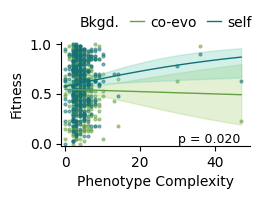

n Series: 39  n rows: 780
['none', 'self']
Categories (2, object): ['none', 'self']
                               GEE Regression Results                               
Dep. Variable:        Q('Focal Prevalence')   No. Observations:                  764
Model:                                  GEE   No. clusters:                       39
Method:                         Generalized   Min. cluster size:                  18
                       Estimating Equations   Max. cluster size:                  20
Family:                            Binomial   Mean cluster size:                19.6
Dependence structure:        Autoregressive   Num. iterations:                     6
Date:                      Sun, 06 Sep 2026   Scale:                           1.000
Covariance type:                     robust   Time:                         03:30:39
                                                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------

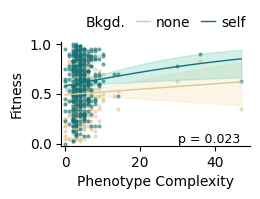

In [20]:
dfjx = dfj[
    dfj["Stint"].isin(range(10, 101, 10))
    & (dfj["Series"] != 16005)
].groupby(["Series", "kind", "Stint"]).mean().reset_index(
    drop=False,
)

fas = "Cardinal Interface Complexity"

for other in ["eco", "none"]:
    d = dfjx[
        dfjx["kind"].isin(["self", other])
    ].copy().replace({"eco": "co-evo"}).copy()
    if other == "eco":
        other = "co-evo"
    d["kind"] = pd.Categorical(
        d["kind"],
        categories=[other, "self"],
    )

    print("n Series:", d["Series"].nunique(), " n rows:", len(d))
    print(d["kind"].unique())

    gee = smf.gee(
        "Q('Focal Prevalence') ~ C(kind) * Q('Cardinal Interface Complexity')",
        groups="Series",
        data=d,
        family=sm.families.Binomial(),
        time="Stint",
        cov_struct=cov_structs.Autoregressive(
            grid=True,
        ),
    ).fit()
    print(gee.summary())
    print(gee.cov_struct.summary())  # within-Series correlation

    cic = "Cardinal Interface Complexity"
    light_palette = {"self": "#6dceb1", "co-evo": "#a3cf73", "none": "#f2dfae"}
    dark_palette = {"self": "#137177", "co-evo": "#66a044", "none": "#dac796"}

    grid = np.linspace(d[cic].min(), d[cic].max(), 100)

    with tp.teed(
        plt.subplots,
        figsize=(2.7, 1.8),
        teeplot_outattrs={"what": "disagg-excl", "other": other},
        teeplot_subdir=teeplot_subdir,
    ) as (fig, ax):
        for kind in [other, "self"]:
            newdata = pd.DataFrame({"kind": kind, cic: grid})
            pred = gee.get_prediction(newdata)
            mean = pred.predicted_mean
            ci = pred.conf_int()

            ax.plot(grid, mean, color=dark_palette[kind], lw=1, label=kind)
            ax.fill_between(
                grid, ci[:, 0], ci[:, 1], color=light_palette[kind], alpha=0.3
            )

            sub = d[d["kind"] == kind]
            ax.scatter(
                sub[cic],
                sub["Focal Prevalence"],
                color=dark_palette[kind],
                s=4,
                alpha=0.5,
                edgecolor=dark_palette[kind],
            )

        ax.set_xlabel("Phenotype Complexity")
        ax.set_ylabel("Fitness")
        ax.set_ylim(-0.02, 1.02)
        ax.set_xlim(-1, None)
        ax.legend(frameon=False, title="Background", fontsize=8)
        fig.tight_layout()
        sns.despine()

        handles, labels = ax.get_legend_handles_labels()
        empty_handle = mlines.Line2D([], [], color="none")
        handles.insert(0, empty_handle)
        labels.insert(0, "Bkgd.")
        ax.legend(handles, labels)
        sns.move_legend(
            ax,
            loc="lower center",
            bbox_to_anchor=(0.5, 1),
            ncol=3,
            columnspacing=0.8,
            title=None,
            frameon=False,
            handletextpad=0.4,
            handlelength=1.0,
        )
        interaction_key = "C(kind)[T.self]:Q('Cardinal Interface Complexity')"
        p_val = gee.pvalues.get(interaction_key, gee.pvalues.iloc[-1])

        # Format the p-value string
        p_text = "p < 0.001" if p_val < 0.001 else f"p = {p_val:.3f}"

        # Add to the upper right corner using axes coordinates
        ax.text(
            0.95, 0,
            p_text,
            transform=ax.transAxes, # Use axes bounding box, not data units
            ha="right",           # Align the right edge of the text to 0.95
            va="bottom",             # Align the top edge of the text to 0.95
            fontsize=9,
            color="black"
        )


## Correlate vs. Self-Adaptation


n Series: 40  n rows: 800
['co-evo', 'self']
Categories (2, object): ['co-evo', 'self']
     Series Stint Cardinal Interface Complexity Focal Prevalence       
kind                                                      co-evo   self
0     16000    10                           2.0            0.325  0.350
1     16000    20                           5.0            0.550  0.750
2     16000    30                           4.0            0.800  0.800
3     16000    40                           4.0            0.825  0.900
4     16000    50                           5.0            0.900  0.950
..      ...   ...                           ...              ...    ...
387   16039    60                           2.0            0.850  0.725
388   16039    70                           2.0            0.400  0.450
389   16039    80                           2.0            0.175  0.300
390   16039    90                           7.0            0.400  0.375
391   16039   100                           2.0 

<ipython-input-21-4b5ff756d04a>:43: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  data=dd.groupby("Series").mean().reset_index(),
<ipython-input-21-4b5ff756d04a>:54: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  dd.groupby("Series").mean()[cic],
<ipython-input-21-4b5ff756d04a>:55: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  dd.groupby("Series").mean()["Self Adaptation"],
<ipython-input-21-4b5ff756d04a>:58: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  dd.groupby("Series").mean()[cic],
<ipython-input-21-4b5ff756d04a>:59: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  dd.groupby("Series").mean()["Self Adaptation"],


teeplots/2026-08-29-pcomplexity-gee-0s/other=co-evo+viz=subplots+what=self-adaptation+ext=.png


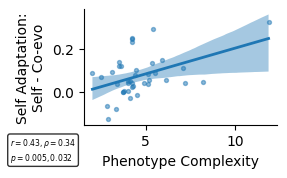

n Series: 40  n rows: 800
['none', 'self']
Categories (2, object): ['none', 'self']
     Series Stint Cardinal Interface Complexity Focal Prevalence       
kind                                                        none   self
0     16000    10                           2.0         0.300000  0.350
1     16000    20                           5.0         0.550000  0.750
2     16000    30                           4.0         0.875000  0.800
3     16000    40                           4.0         0.825000  0.900
4     16000    50                           5.0         0.875000  0.950
..      ...   ...                           ...              ...    ...
387   16039    60                           2.0         0.575000  0.725
388   16039    70                           2.0         0.275000  0.450
389   16039    80                           2.0         0.263158  0.300
390   16039    90                           7.0         0.375000  0.375
391   16039   100                           2.0     

<ipython-input-21-4b5ff756d04a>:43: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  data=dd.groupby("Series").mean().reset_index(),
<ipython-input-21-4b5ff756d04a>:54: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  dd.groupby("Series").mean()[cic],
<ipython-input-21-4b5ff756d04a>:55: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  dd.groupby("Series").mean()["Self Adaptation"],
<ipython-input-21-4b5ff756d04a>:58: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  dd.groupby("Series").mean()[cic],
<ipython-input-21-4b5ff756d04a>:59: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  dd.groupby("Series").mean()["Self Adaptation"],


teeplots/2026-08-29-pcomplexity-gee-0s/other=none+viz=subplots+what=self-adaptation+ext=.png


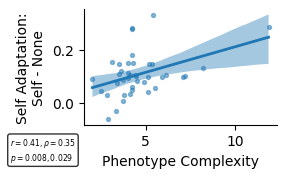

In [21]:
dfjx = dfj[
    dfj["Stint"].isin(range(10, 101, 10))
].groupby(["Series", "kind", "Stint"]).mean().reset_index(
    drop=False,
)

fas = "Cardinal Interface Complexity"

for other in ["eco", "none"]:
    d = dfjx[
        dfjx["kind"].isin(["self", other])
    ].copy().replace({"eco": "co-evo"}).copy()
    if other == "eco":
        other = "co-evo"
    d["kind"] = pd.Categorical(
        d["kind"],
        categories=[other, "self"],
    )

    print("n Series:", d["Series"].nunique(), " n rows:", len(d))
    print(d["kind"].unique())

    cic = "Cardinal Interface Complexity"
    dd = d.pivot_table(
        index=["Series", "Stint", cic],
        columns=["kind"],
        values=["Focal Prevalence"],
    ).reset_index()
    print(dd)
    dd["Self Adaptation"] = dd["Focal Prevalence"]["self"] - dd["Focal Prevalence"][other]

    light_palette = {"self": "#6dceb1", "co-evo": "#a3cf73", "none": "#f2dfae"}
    dark_palette = {"self": "#137177", "co-evo": "#66a044", "none": "#dac796"}

    with tp.teed(
        plt.subplots,
        figsize=(2.7, 1.8),
        teeplot_outattrs={"what": "self-adaptation", "other": other},
        teeplot_subdir=teeplot_subdir,
    ) as (fig, ax):

        sns.regplot(
            data=dd.groupby("Series").mean().reset_index(),
            x=cic,
            y="Self Adaptation",
            scatter_kws={"s": 8, "alpha": 0.5},
            line_kws={"lw": 2},
            ci=95,
        )

        sns.despine(ax=ax)

        spear_r, spear_p = scipy_stats.spearmanr(
            dd.groupby("Series").mean()[cic],
            dd.groupby("Series").mean()["Self Adaptation"],
        )
        pear_r, pear_p = scipy_stats.pearsonr(
            dd.groupby("Series").mean()[cic],
            dd.groupby("Series").mean()["Self Adaptation"],
        )

        # Format the annotation string
        stats_text = (
            fr"$r={pear_r:.2f},\rho={spear_r:.2f}$"
            + f"\n$p={pear_p:.3f},{spear_p:.3f}$"
        )
        print(stats_text)

        ax.collections[1].set_alpha(0.4)
        sns.despine(ax=ax)
        ax.figure.set_size_inches(2.5, 1.5)
        ax.text(-0.38, -0.1, stats_text,
                transform=ax.transAxes,
                fontsize=5.5,
                verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
        )

        ax.set_xlabel("Phenotype Complexity")
        sub = {
            "co-evo": "\nSelf - Co-evo",
            "none": "\nSelf - None",
        }[other]
        ax.set_ylabel(
            "Self Adaptation:" + sub,
        )
